# Project 2: Data Classification Using AI
### DecodeLabs — Artificial Intelligence Engineer Track

**Goal:** Build a basic classification model using a small dataset (the Iris dataset), following the complete supervised learning pipeline: data loading, preprocessing, train-test split, model training, prediction, and evaluation.

**Key Requirements Covered:**
- Load and understand a dataset
- Split data into training and testing sets
- Apply a simple classification algorithm (K-Nearest Neighbors)

**Key Skills:** Data handling, supervised learning basics, model training and evaluation.

---


## 1. Introduction

Traditional programming relies on hard-coded, heuristic rules (if-else logic) to make decisions. Supervised Learning takes a fundamentally different approach: instead of writing the rules ourselves, we provide the machine with historical data (examples with known outcomes), and it derives the underlying logic on its own.

This notebook follows the **IPO Framework** (Input -> Process -> Output) to build, train, test, and validate a classification model:

| Stage | Components |
|---|---|
| **Input** | Iris dataset, Feature scaling |
| **Process** | Train-test split, KNN algorithm |
| **Output** | Confusion matrix, F1 score |


## 2. Import Required Libraries

We import the core libraries needed for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load and Understand the Dataset

**Raw Material: The Iris Benchmark**

The Iris dataset is a classic, well-balanced benchmark dataset for classification tasks.

- **Samples:** 150 (balanced across classes)
- **Classes:** 3 (Setosa, Versicolor, Virginica)
- **Dimensions (Features):** 4 (Sepal Length, Sepal Width, Petal Length, Petal Width)

Each sample represents a flower, described by four numeric measurements, and labeled with one of three species.


In [2]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map({i: name for i, name in enumerate(iris.target_names)})

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# Basic dataset understanding
print("Class distribution:")
print(df["species"].value_counts())
print()
print("Statistical summary:")
df.describe()


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


### 3.1 Exploratory Visualization

Visualizing the relationship between features helps confirm that the classes are separable, which supports the choice of a distance-based algorithm like K-Nearest Neighbors.


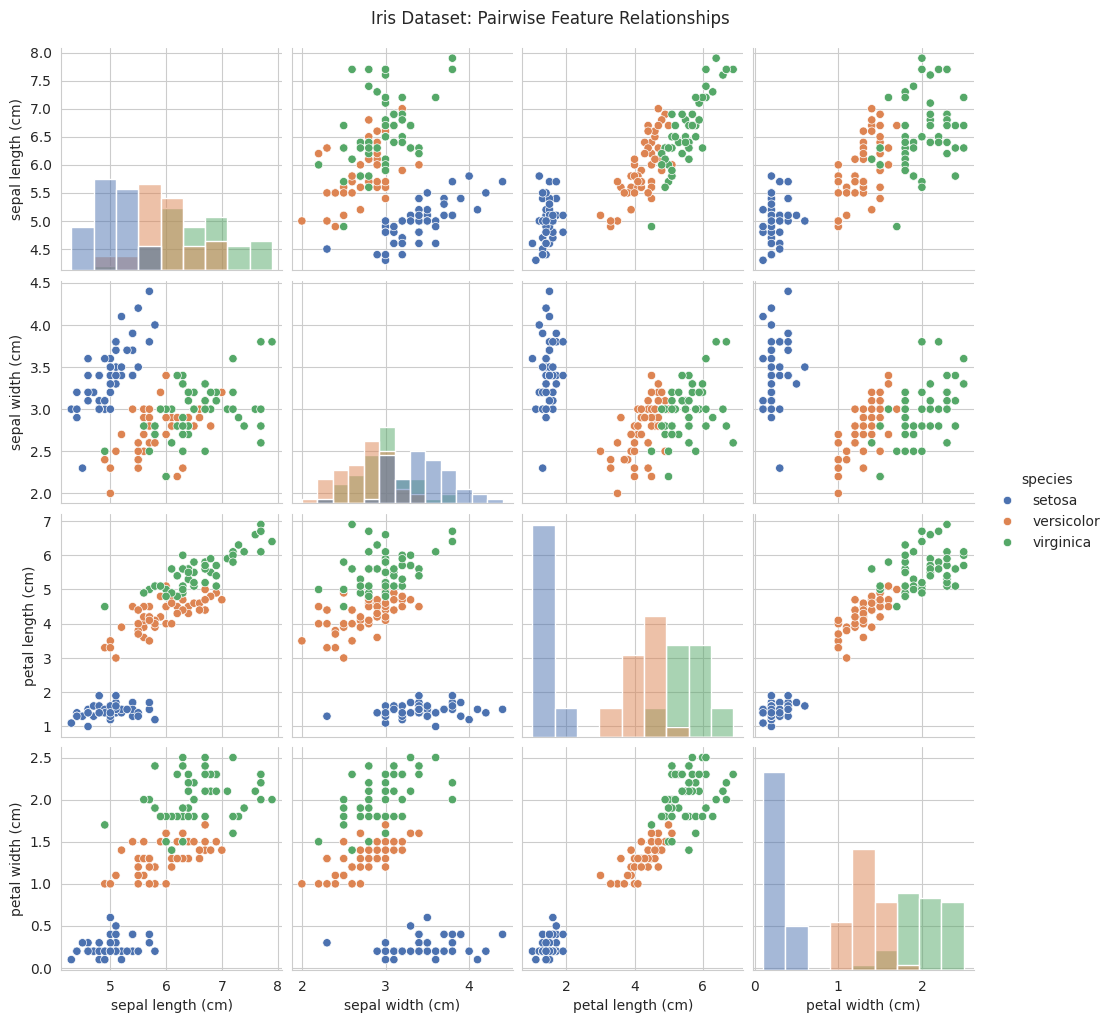

In [5]:
sns.pairplot(df.drop(columns=["target"]), hue="species", diag_kind="hist", palette="deep")
plt.suptitle("Iris Dataset: Pairwise Feature Relationships", y=1.02)
plt.show()


## 4. Data Preprocessing: Feature Scaling

**The Gatekeeper Rule: Scaling**

KNN is a distance-based algorithm. If features are on different scales (raw, unscaled data), features with larger numeric ranges dominate the distance calculation and bias the model. `StandardScaler` transforms each feature so that:

- **Mean = 0**
- **Variance = 1**

This ensures every feature contributes fairly to the distance metric.


In [6]:
X = df[iris.feature_names]
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=iris.feature_names)
print("Scaled feature summary (mean approx 0, std approx 1):")
X_scaled_df.describe().loc[["mean", "std"]]


Scaled feature summary (mean approx 0, std approx 1):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00


## 5. Structural Integrity: The Train-Test Split

Before training, the dataset is split into a **Training Set** (used for pattern recognition) and a **Test Set** (used for validation on unseen data). The data is shuffled before splitting to remove any ordering bias.

We use an 80/20 split, a standard convention balancing enough data to learn patterns with enough held-out data to validate honestly.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 120 samples
Test set size: 30 samples


## 6. The Algorithm: K-Nearest Neighbors (KNN)

**The Proximity Principle:** Similar things exist in close proximity.

KNN classifies a new data point by looking at its `K` closest neighbors in the training data and assigning the majority class among them. It requires no explicit "training" of internal parameters — it simply memorizes the training data and computes distances at prediction time.


### 6.1 Tuning the Engine: Choosing K

Choosing `K` is a balance:

- **K too small** (e.g., K=1): the model is sensitive to noise and overfits.
- **K too large** (e.g., K=100): the model becomes too generic and underfits.

The optimal K is typically found at the "elbow" of the error rate curve, where error is minimized before it starts rising again due to underfitting.


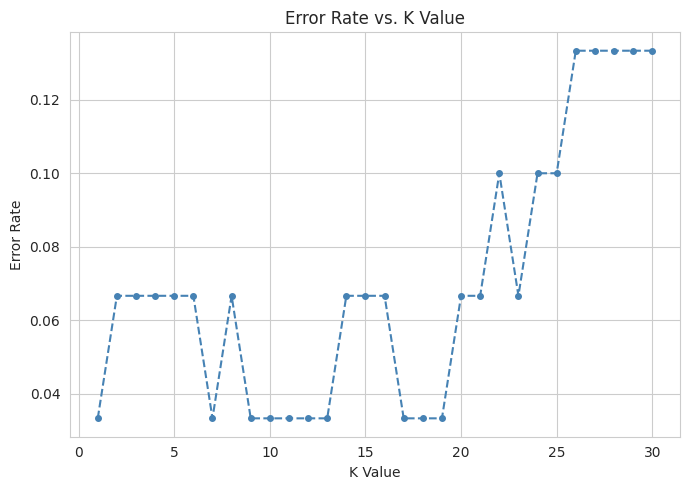

Optimal K based on lowest error rate: 1


In [8]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(np.mean(pred_temp != y_test))

plt.plot(k_range, error_rates, marker="o", markersize=4, linestyle="--", color="steelblue")
plt.title("Error Rate vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmin(error_rates)]
print(f"Optimal K based on lowest error rate: {optimal_k}")


### 6.2 The Workflow: Instantiate, Fit, Predict

With the optimal K identified, we follow the standard scikit-learn workflow:

1. **Instantiate** — build the model frame
2. **Fit** — the model memorizes the training data
3. **Predict** — the model applies its logic to unseen test data


In [9]:
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model training complete.")
print(f"Number of test predictions made: {len(predictions)}")


Model training complete.
Number of test predictions made: 30


## 7. Output Validation

**Accuracy alone can be misleading** — especially on imbalanced datasets, where a model can score high accuracy while consistently failing on the minority class. We therefore inspect the results using a **Confusion Matrix**, which breaks predictions into four categories:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) — Missed Detection |
| **Actual Negative** | False Positive (FP) — False Alarm | True Negative (TN) |


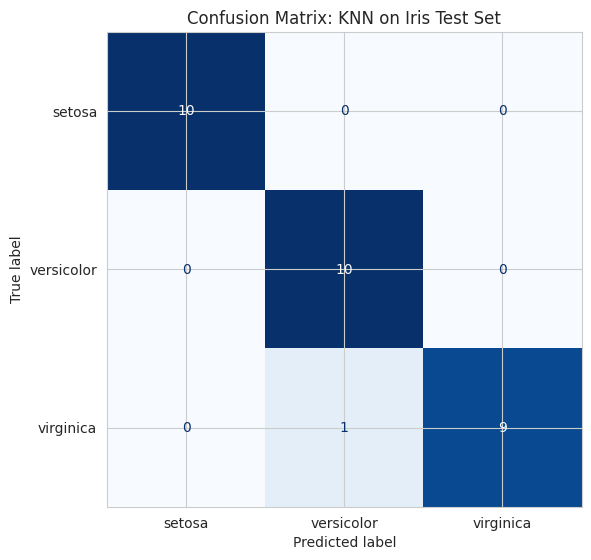

In [10]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: KNN on Iris Test Set")
plt.tight_layout()
plt.show()


## 8. Strategic Trade-offs: Precision, Recall, and F1 Score

- **Precision** answers: *Of all predicted positives, how many were correct?* (Important for trustworthiness, e.g. spam filters.)
- **Recall** answers: *Of all actual positives, how many did we catch?* (Important for sensitivity, e.g. medical diagnosis.)
- **F1 Score** is the harmonic mean of Precision and Recall, balancing both concerns into a single metric.


In [11]:
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
print()
print("Full Classification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))


Accuracy: 0.9667
Weighted F1 Score: 0.9666

Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 9. Full Architecture Summary

The complete pipeline built in this notebook:

**Input:** Iris dataset (150 samples, 4 features, 3 classes) -> Feature scaling with StandardScaler
**Process:** 80/20 train-test split -> K-Nearest Neighbors classifier (tuned K)
**Output:** Confusion matrix -> Precision, Recall, F1 Score

This mirrors the standard supervised learning workflow used across most classical machine learning tasks, independent of the specific algorithm chosen.


## 10. Emerging Horizons

This project used structured, tabular data. The same core principles — input, process, output, train-test split, and evaluation metrics — extend to more complex data types, such as images, where each pixel becomes a feature. This is the conceptual bridge from classical Machine Learning (as used here) to Deep Learning and Convolutional Neural Networks (CNNs) for Computer Vision.


## 11. Conclusion

The best way to master Artificial Intelligence is through hands-on practice, not just theory. This notebook implemented the full supervised learning pipeline on the Iris dataset:

1. Loaded and explored the dataset
2. Scaled features using `StandardScaler`
3. Split data into training and test sets
4. Tuned and trained a K-Nearest Neighbors classifier
5. Validated performance using a confusion matrix, precision, recall, and F1 score

**Suggested next steps for further experimentation:**
- Compare KNN against other algorithms (e.g., Logistic Regression, Decision Trees, SVM)
- Test the trained model on new, unseen data
- Treat any low accuracy score as a learning opportunity to refine preprocessing or model choice
